# LAB 4:  BÀI THỰC HÀNH CHUẨN BỊ DỮ LIỆU 

## PHẦN 1: DATA CLEANSING & FEATURE ENGINEERING

In [118]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

load_data = pd.read_csv(r"D:\Hoc_Tap\HK252\Phân Tích Dữ Liệu Và Học Sâu\Tuan04\titanic_disaster.csv", on_bad_lines='skip')
load_data.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


2. Thống kê dữ liệu thiếu trên các biến số và trực quan hóa dữ liệu thiếu bằng biểu đồ (Heat 
map). Hãy cho nhận xét về tình trạng thiếu dữ liệu Age, Cabin và Embarked 

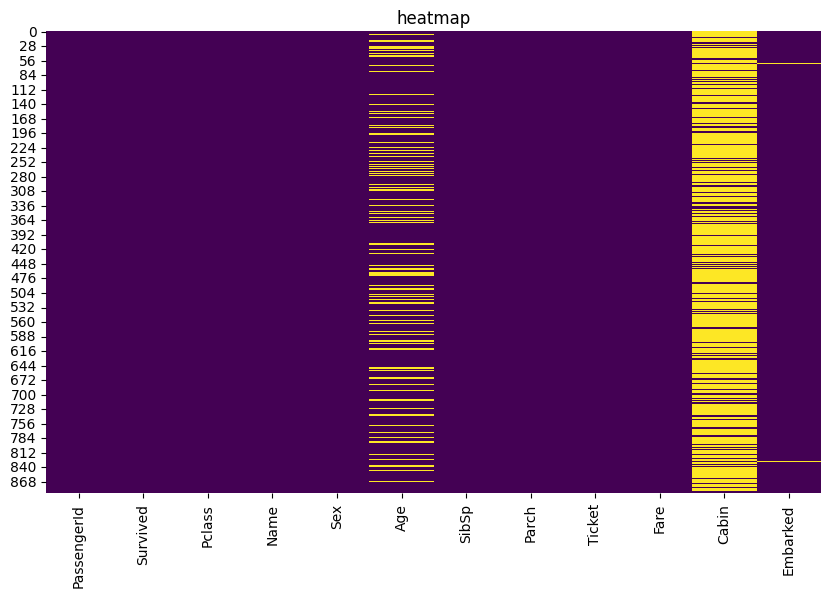

In [119]:
plt.figure(figsize=(10, 6))
sns.heatmap(load_data.isnull(), cbar=False, cmap='viridis')
plt.title('heatmap')
plt.show()
# về nhà viết nhận xét

3. Xử lý tên cột tên Name, tách ra làm 2 cột: firstName và secondName. Lưu ý: Sau khi 
tách cột xong thì xóa luôn cột Name 

In [120]:
load_data[['firstName', 'secondName']] = load_data['Name'].str.split(',', expand=True, n=1)
load_data.drop('Name', axis=1, inplace=True)
load_data

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,firstName,secondName
0,1,0,3,male,22.0,1,0,A/5 21171,7.2500,NaN,S,Braund,Mr. Owen Harris
1,2,1,1,female,38.0,1,0,PC 17599,71.2833,C85,C,Cumings,Mrs. John Bradley (Florence Briggs Thayer)
2,3,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Heikkinen,Miss. Laina
3,4,1,1,female,35.0,1,0,113803,53.1000,C123,S,Futrelle,Mrs. Jacques Heath (Lily May Peel)
4,5,0,3,male,35.0,0,0,373450,8.0500,NaN,S,Allen,Mr. William Henry
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,male,27.0,0,0,211536,13.0000,NaN,S,Montvila,Rev. Juozas
887,888,1,1,female,19.0,0,0,112053,30.0000,B42,S,Graham,Miss. Margaret Edith
888,889,0,3,female,NaN,1,2,W./C. 6607,23.4500,NaN,S,Johnston,"Miss. Catherine Helen ""Carrie"""
889,890,1,1,male,26.0,0,0,111369,30.0000,C148,C,Behr,Mr. Karl Howell


4. Xứ lý rút gọn kích thước dữ liệu trên cột Sex như sau: thay thế male → M và female → F 

In [121]:
load_data['Sex'] = load_data['Sex'].map({'male': 'M', 'female': 'F'})
load_data

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,firstName,secondName
0,1,0,3,M,22.0,1,0,A/5 21171,7.2500,NaN,S,Braund,Mr. Owen Harris
1,2,1,1,F,38.0,1,0,PC 17599,71.2833,C85,C,Cumings,Mrs. John Bradley (Florence Briggs Thayer)
2,3,1,3,F,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Heikkinen,Miss. Laina
3,4,1,1,F,35.0,1,0,113803,53.1000,C123,S,Futrelle,Mrs. Jacques Heath (Lily May Peel)
4,5,0,3,M,35.0,0,0,373450,8.0500,NaN,S,Allen,Mr. William Henry
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,M,27.0,0,0,211536,13.0000,NaN,S,Montvila,Rev. Juozas
887,888,1,1,F,19.0,0,0,112053,30.0000,B42,S,Graham,Miss. Margaret Edith
888,889,0,3,F,NaN,1,2,W./C. 6607,23.4500,NaN,S,Johnston,"Miss. Catherine Helen ""Carrie"""
889,890,1,1,M,26.0,0,0,111369,30.0000,C148,C,Behr,Mr. Karl Howell


5. Xử lý dữ liệu thiếu trên biến Age bằng cách thay thế bằng giá trị trung bình tuổi: Hãy đưa ra quyết định dùng giá trị trung bình tuổi toàn bộ hành khách hay theo từng nhóm hạng vé (hạng hành khách: Pclass). Ta tiến hành làm các bước sau 
- a. Sử dụng Seaborn để vẽ biểu đồ (Box plot) trực quan dữ liệu để xác định phân 
phối tuổi trên từng hạng hành khách. Nhận xét về tuổi trung bình giữa các nhóm 
hành khách. Từ đó đưa ra quyết định cách thay thế giá trị tuổi bị thiếu. 
- b. Tiến hành thay thế giá trị Age bị thiếu. Sau đó, hiển thị kết quả dạng bảng và trực 
quan dữ liệu đã xử lý thiếu cho cột’Age’ bằng biểu đồ Heat map.

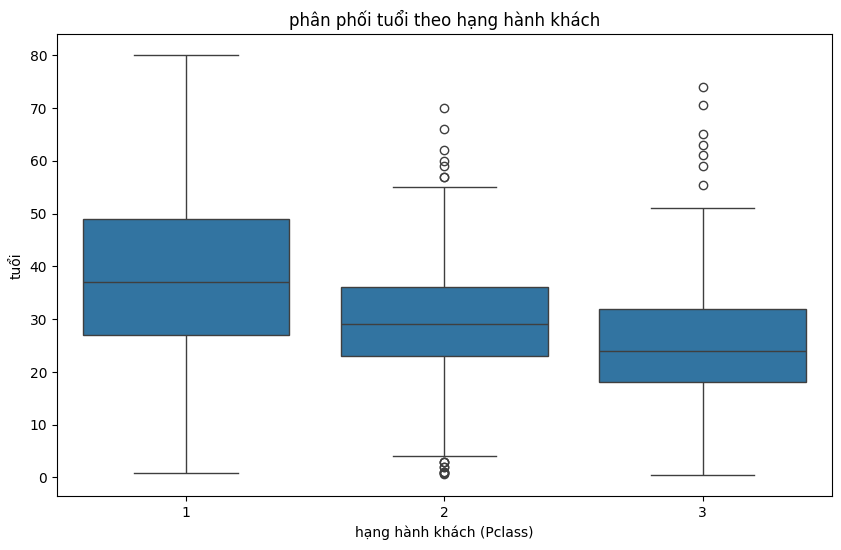

In [122]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Pclass', y='Age', data=load_data)
plt.title('phân phối tuổi theo hạng hành khách')
plt.xlabel('hạng hành khách (Pclass)')
plt.ylabel('tuổi')

mean_ages = load_data.groupby('Pclass')['Age'].mean()

,PassengerId,Pclass,Age
0,1,3,22.0
1,2,1,38.0
2,3,3,26.0
3,4,1,35.0
4,5,3,35.0
5,6,3,25.0
6,7,1,54.0
7,8,3,2.0
8,9,3,27.0
9,10,2,14.0


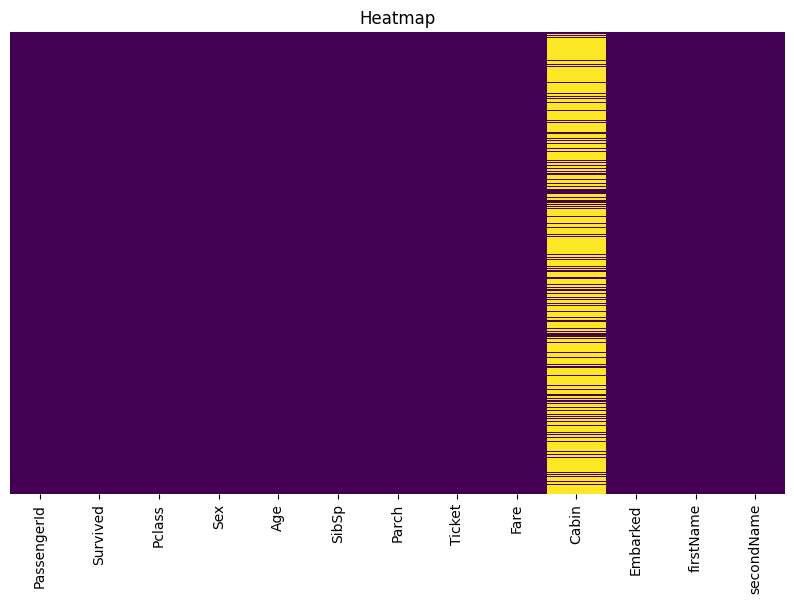

In [123]:
load_data.loc[(load_data['Age'].isnull()) & (load_data['Pclass'] == 1), 'Age'] = 38
load_data.loc[(load_data['Age'].isnull()) & (load_data['Pclass'] == 2), 'Age'] = 30
load_data.loc[(load_data['Age'].isnull()) & (load_data['Pclass'] == 3), 'Age'] = 25
plt.figure(figsize=(10, 6))
sns.heatmap(load_data.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Heatmap')
load_data[['PassengerId', 'Pclass', 'Age']].head(10)


6. Xây dựng biến số Agegroup có thang đo thứ tự được ánh xạ theo thang đo khoảng dựa 
trên độ tuổi của hành khách như sau: (age =< 12] → Kid; (12, 18]: Teen, (18, 60]: Adult 
và ( age > 60): Older 

In [124]:
dotuoi = [0, 12, 18, 60, np.inf]
thehe = ['Kid', 'Teen', 'Adult', 'Older']
load_data['Agegroup'] = pd.cut(load_data['Age'], bins=dotuoi, labels=thehe, right=True)
load_data

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,firstName,secondName,Agegroup
0,1,0,3,M,22.0,1,0,A/5 21171,7.2500,NaN,S,Braund,Mr. Owen Harris,Adult
1,2,1,1,F,38.0,1,0,PC 17599,71.2833,C85,C,Cumings,Mrs. John Bradley (Florence Briggs Thayer),Adult
2,3,1,3,F,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Heikkinen,Miss. Laina,Adult
3,4,1,1,F,35.0,1,0,113803,53.1000,C123,S,Futrelle,Mrs. Jacques Heath (Lily May Peel),Adult
4,5,0,3,M,35.0,0,0,373450,8.0500,NaN,S,Allen,Mr. William Henry,Adult
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,M,27.0,0,0,211536,13.0000,NaN,S,Montvila,Rev. Juozas,Adult
887,888,1,1,F,19.0,0,0,112053,30.0000,B42,S,Graham,Miss. Margaret Edith,Adult
888,889,0,3,F,25.0,1,2,W./C. 6607,23.4500,NaN,S,Johnston,"Miss. Catherine Helen ""Carrie""",Adult
889,890,1,1,M,26.0,0,0,111369,30.0000,C148,C,Behr,Mr. Karl Howell,Adult


7. Tiến hành thêm đặc trưng về danh xưng (namePrefix) trong xã hội bằng cách tách  Mr, 
Mrs, Miss, Master ra khỏi “secondName” 

In [125]:
load_data['namePrefix'] = load_data['secondName'].apply(lambda x: x.split('.')[0].strip())
load_data[['secondName', 'namePrefix']]

,secondName,namePrefix
0,Mr. Owen Harris,Mr
1,Mrs. John Bradley (Florence Briggs Thayer),Mrs
2,Miss. Laina,Miss
3,Mrs. Jacques Heath (Lily May Peel),Mrs
4,Mr. William Henry,Mr
...,...,...
886,Rev. Juozas,Rev
887,Miss. Margaret Edith,Miss
888,"Miss. Catherine Helen ""Carrie""",Miss
889,Mr. Karl Howell,Mr


8. Khai thác thêm thông tin số lượng thành viên đi theo nhóm thân quen (familySize) đối 
với mỗi hành khách trên chuyến hải trình; family size = 1+ SibSp + Parch 

In [126]:
load_data['familySize'] = 1 + load_data['SibSp'] + load_data['Parch']
load_data[['SibSp', 'Parch', 'familySize']]

,SibSp,Parch,familySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1
...,...,...,...
886,0,0,1
887,0,0,1
888,1,2,4
889,0,0,1


9. Tạo thêm đặc trưng ‘Alone’ để xác định hành khách đi theo nhóm hay cá nhân bằng cách 
dựa trên familySize như sau: Nếu familySize = 0 thì giá trị Alone = 1 và ngược lại là 0

In [127]:
load_data['Alone'] = 0
load_data.loc[load_data['familySize'] == 1, 'Alone'] = 1
load_data[['familySize', 'Alone']]

,familySize,Alone
0,2,0
1,2,0
2,1,1
3,2,0
4,1,1
...,...,...
886,1,1
887,1,1
888,4,0
889,1,1


10. Tiến hành tách loại cabin (typeCabin) mà hành khách ở để lọc và phân tích đặc tính 
cabin. Loại cabin được kí hiệu bởi chữ cái đầu tiên. Lưu ý: Đối với dữ liệu cabin bị thiếu 
thì thay thế bằng “Unknown”

In [128]:
load_data['Cabin'] = load_data['Cabin'].fillna('Unknown')
load_data['typeCabin'] = load_data['Cabin'].str[0]
load_data[['Cabin', 'typeCabin']]

,Cabin,typeCabin
0,Unknown,U
1,C85,C
2,Unknown,U
3,C123,C
4,Unknown,U
...,...,...
886,Unknown,U
887,B42,B
888,Unknown,U
889,C148,C


12. Trực quan thông tin tương quan tỉ lệ sống sót và thiệt mạng trên từng nhóm giới tính. 

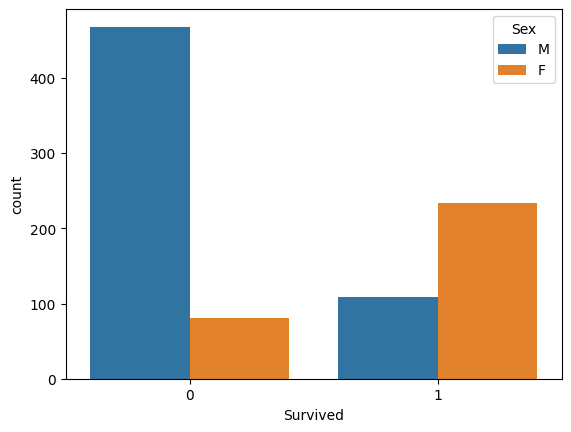

In [129]:
sns.countplot(x='Survived', hue='Sex', data= load_data)
plt.show()

sns.countplot(x='Survived', hue='Pclass', data=df, palette='rainbow')
plt.title('Survival Count by Pclass')
plt.show()

13. Trực quan thông tin hành khách sống sót trên từng nhóm phân loại hành khách (Pclass). 

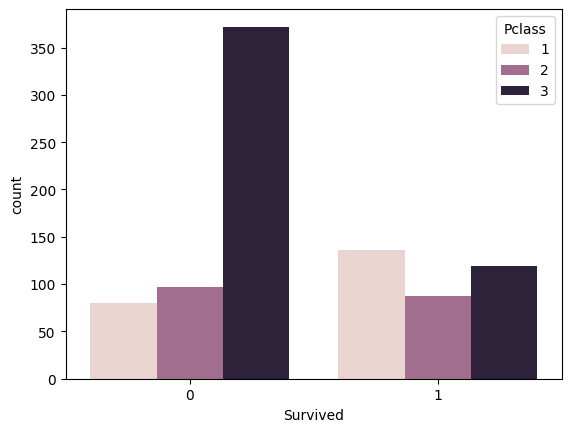

In [ ]:
sns.countplot(x='Survived', hue='Pclass', data= load_data)
plt.show()

14. Trực quan thông tin hành khách sống sót trên từng nhóm giới tính và thang đo tuổi tác 

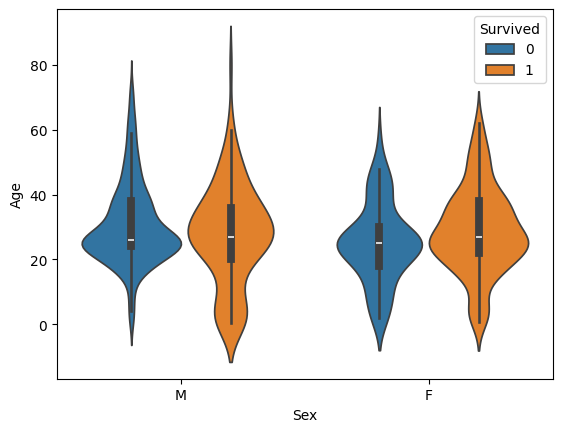

In [131]:
sns.violinplot(x='Sex', y = 'Age',  hue='Survived', data= load_data)
plt.show()

15. Trực quan xác suất hành khách sống sót dựa trên thông tin nhóm đi cùng

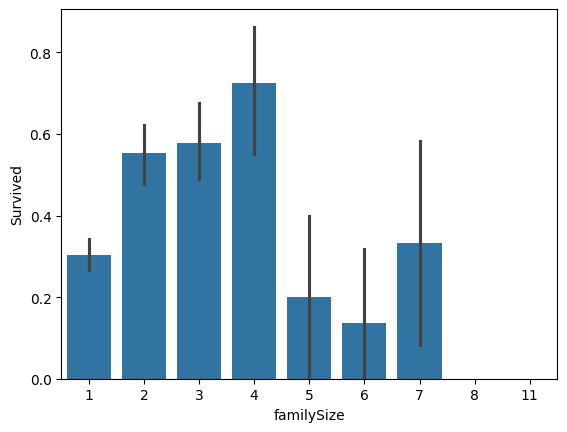

In [132]:
sns.barplot(x='familySize', y='Survived', data=load_data)
plt.show()

16. Trực quan xác suất hành khách sống sót dựa trên thông tin giá vé

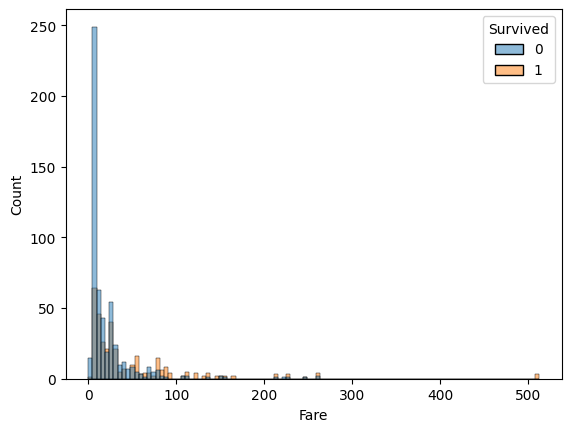

In [133]:
sns.histplot(x='Fare', hue='Survived', data=load_data)
plt.show()

17. Trực quan số lượng người thiệt mạng và sống sót theo phân lớp (Pclass) hành khách và 
cảng sẽ cập bến.

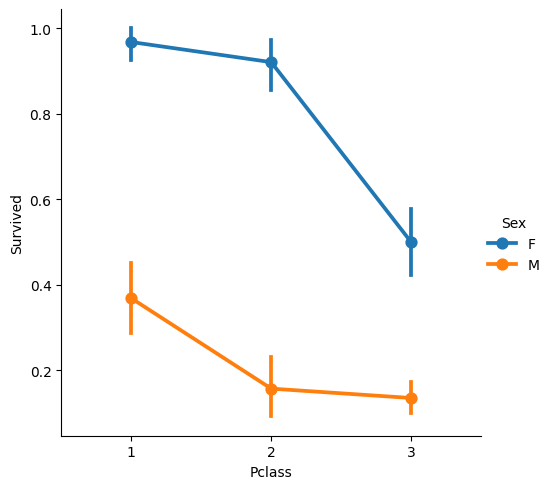

In [134]:
sns.catplot(x='Pclass', y='Survived', hue='Sex', kind= 'point', data= load_data)
plt.show()